# GRANGER CAUSALITY TEST

In [1]:
# ============================================================
# GRANGER CAUSALITY TEST
# ============================================================
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load master dataset
df = pd.read_csv('../data/processed/master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"📊 Data: {len(df)} baris | {df['date'].min()} → {df['date'].max()}")

# ============================================================
# UJI STASIONERITAS (ADF TEST)
# ============================================================
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n📋 {name}")
    print(f"   ADF Statistic: {result[0]:.6f}")
    print(f"   p-value: {result[1]:.6f}")
    print(f"   Critical (5%): {result[4]['5%']:.6f}")
    if result[1] < 0.05:
        print(f"   ✅ STASIONER")
        return True
    else:
        print(f"   ❌ NON-STASIONER → perlu differencing")
        return False

print("=" * 60)
print("UJI STASIONERITAS")
print("=" * 60)

is_stationary_close = adf_test(df['close'], 'IHSG Close')
is_stationary_return = adf_test(df['daily_return'], 'Daily Return')
is_stationary_sentiment = adf_test(df['avg_sentiment'], 'Avg Sentiment (VADER)')

# ============================================================
# PERSIAPAN DATA UNTUK GRANGER
# ============================================================
# Gunakan daily_return (sudah stasioner) dan sentiment
# Kalau sentiment non-stasioner, differencing
df['sentiment_diff'] = df['avg_sentiment'].diff()

# Data untuk test: [target, cause]
# Target = daily_return, Cause = avg_sentiment
df_granger = df[['daily_return', 'avg_sentiment']].dropna()

print(f"\n✅ Data Granger: {len(df_granger)} baris")

# ============================================================
# GRANGER CAUSALITY TEST
# ============================================================
print("\n" + "=" * 60)
print("GRANGER CAUSALITY TEST")
print("=" * 60)
print("H0: Sentimen TIDAK Granger-menyebabkan IHSG Return")
print("H1: Sentimen Granger-menyebabkan IHSG Return")
print("α = 0.05 (signifikan kalau p-value < 0.05)")
print("=" * 60)

max_lag = 5
gc_results = {}

for lag in range(1, max_lag + 1):
    result = grangercausalitytests(df_granger[['daily_return', 'avg_sentiment']], 
                                    maxlag=lag, verbose=False)
    
    # Ambil p-value dari F-test (ssr_ftest)
    p_value = result[lag][0]['ssr_ftest'][1]
    f_stat = result[lag][0]['ssr_ftest'][0]
    
    gc_results[lag] = {'f_stat': f_stat, 'p_value': p_value}
    
    status = "✅ SIGNIFIKAN" if p_value < 0.05 else "❌ Tidak signifikan"
    print(f"Lag {lag}: F={f_stat:.4f}, p-value={p_value:.6f} → {status}")

# ============================================================
# KESIMPULAN
# ============================================================
print("\n" + "=" * 60)
print("KESIMPULAN GRANGER CAUSALITY")
print("=" * 60)

significant_lags = [lag for lag, res in gc_results.items() if res['p_value'] < 0.05]

if significant_lags:
    print(f"🎯 Sentimen VADER Granger-menyebabkan IHSG Return pada lag: {significant_lags}")
    print(f"   Artinya: sentimen hari ini bisa prediksi arah IHSG {min(significant_lags)}-{max(significant_lags)} hari ke depan")
else:
    print(f"🎯 Tidak ada bukti Granger Causality dari sentimen VADER ke IHSG Return")
    print(f"   Kemungkinan: (1) hubungan memang tidak ada, atau (2) VADER kurang akurat untuk bahasa Indonesia")

print("=" * 60)

📊 Data: 1407 baris | 2019-03-14 00:00:00 → 2024-12-30 00:00:00
UJI STASIONERITAS

📋 IHSG Close
   ADF Statistic: -1.339539
   p-value: 0.610895
   Critical (5%): -2.863620
   ❌ NON-STASIONER → perlu differencing

📋 Daily Return
   ADF Statistic: -8.751445
   p-value: 0.000000
   Critical (5%): -2.863626
   ✅ STASIONER

📋 Avg Sentiment (VADER)
   ADF Statistic: -37.625353
   p-value: 0.000000
   Critical (5%): -2.863598
   ✅ STASIONER

✅ Data Granger: 1407 baris

GRANGER CAUSALITY TEST
H0: Sentimen TIDAK Granger-menyebabkan IHSG Return
H1: Sentimen Granger-menyebabkan IHSG Return
α = 0.05 (signifikan kalau p-value < 0.05)
Lag 1: F=2.0388, p-value=0.153555 → ❌ Tidak signifikan
Lag 2: F=1.7472, p-value=0.174640 → ❌ Tidak signifikan
Lag 3: F=1.2899, p-value=0.276347 → ❌ Tidak signifikan
Lag 4: F=1.3019, p-value=0.267247 → ❌ Tidak signifikan
Lag 5: F=2.1293, p-value=0.059522 → ❌ Tidak signifikan

KESIMPULAN GRANGER CAUSALITY
🎯 Tidak ada bukti Granger Causality dari sentimen VADER ke IHSG Re

c:\Users\ADVAN\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADVAN\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADVAN\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADVAN\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADVAN\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# VAR MODEL 

📊 Data VAR: 1407 baris
       daily_return  avg_sentiment  volatility_20d
count   1407.000000    1407.000000     1407.000000
mean       0.000124       0.003741        0.137019
std        0.009956       0.059018        0.077056
min       -0.065787      -0.585900        0.049735
25%       -0.004759       0.000000        0.097172
50%        0.000465       0.000000        0.118627
75%        0.005284       0.000000        0.151811
max        0.101907       0.585900        0.671505

⏳ Mencari lag optimal...
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -19.99      -19.98   2.080e-09      -19.99
1       -23.84     -23.79*   4.431e-11      -23.82
2       -23.87      -23.79   4.302e-11      -23.84
3       -23.90      -23.79   4.175e-11     -23.86*
4       -23.90      -23.76   4.155e-11      -23.85
5       -23.92      -23.74   4.098e-11      -23.85
6       -23.91      -23.70   4.13

<Figure size 1200x800 with 0 Axes>

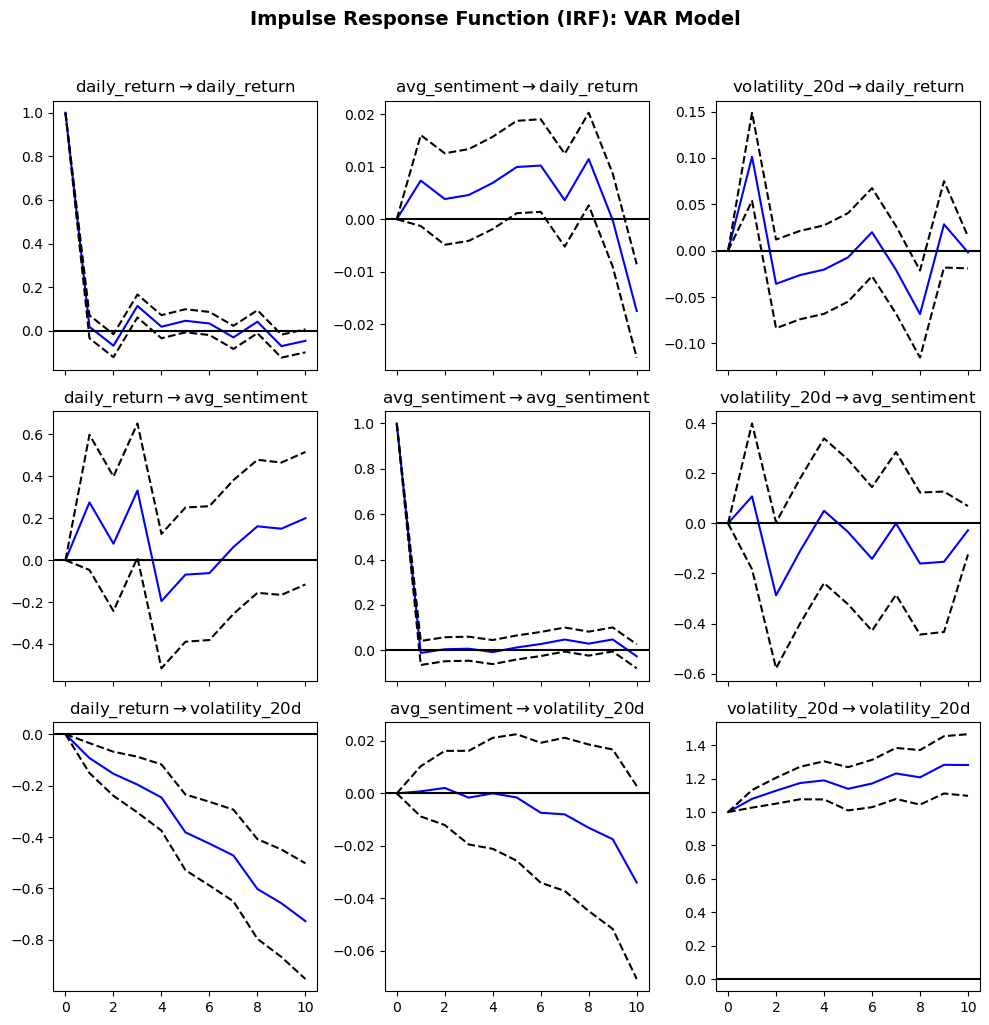

💾 Disimpan: reports/figures/impulse_response_var.png

⏳ Forecast Error Variance Decomposition...


<Figure size 1000x600 with 0 Axes>

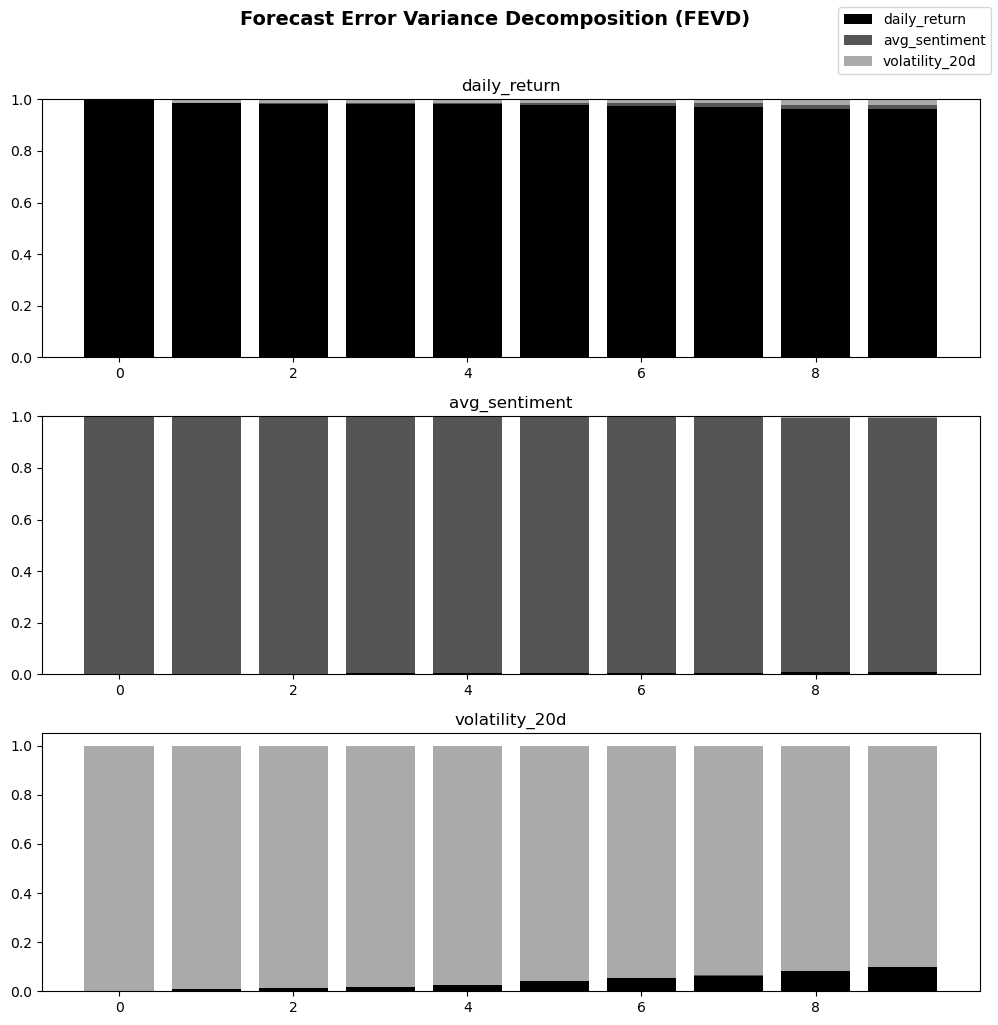

💾 Disimpan: reports/figures/fevd_var.png

📋 FEVD Summary:
FEVD for daily_return
     daily_return  avg_sentiment  volatility_20d
0        1.000000       0.000000        0.000000
1        0.985621       0.002008        0.012371
2        0.983641       0.002530        0.013829
3        0.982292       0.003257        0.014451
4        0.980131       0.004963        0.014906
5        0.976653       0.008464        0.014884
6        0.972590       0.012142        0.015269
7        0.971676       0.012582        0.015742
8        0.962040       0.017024        0.020937
9        0.961335       0.016926        0.021738

FEVD for avg_sentiment
     daily_return  avg_sentiment  volatility_20d
0        0.000194       0.999806        0.000000
1        0.002137       0.997486        0.000378
2        0.002342       0.994602        0.003055
3        0.005324       0.991236        0.003440
4        0.006354       0.990128        0.003519
5        0.006469       0.989975        0.003556
6        0.006

In [2]:
# ============================================================
# VAR MODEL (Vector Autoregression)
# ============================================================
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# Data untuk VAR (harus stasioner dan tidak ada NaN)
df_var = df[['daily_return', 'avg_sentiment', 'volatility_20d']].dropna()

print(f"📊 Data VAR: {len(df_var)} baris")
print(df_var.describe())

# Pilih lag optimal pakai AIC
print("\n⏳ Mencari lag optimal...")
model_var = VAR(df_var)
lag_results = model_var.select_order(maxlags=10)
print(lag_results.summary())

# Pilih lag dengan AIC terkecil
optimal_lag = lag_results.selected_orders['aic']
print(f"\n✅ Lag optimal (AIC): {optimal_lag}")

# Fit model
results_var = model_var.fit(optimal_lag)
print("\n" + "="*60)
print("HASIL ESTIMASI VAR")
print("="*60)
print(results_var.summary())

# ============================================================
# IMPULSE RESPONSE FUNCTION (IRF)
# ============================================================
print("\n⏳ Menghitung Impulse Response Function...")

irf = results_var.irf(10)  # 10 periode ke depan

fig = plt.figure(figsize=(12, 8))
irf.plot()
plt.suptitle('Impulse Response Function (IRF): VAR Model', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\impulse_response_var.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/impulse_response_var.png")

# ============================================================
# FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# ============================================================
print("\n⏳ Forecast Error Variance Decomposition...")
fevd = results_var.fevd(10)

fig = plt.figure(figsize=(10, 6))
fevd.plot()
plt.suptitle('Forecast Error Variance Decomposition (FEVD)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\fevd_var.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/fevd_var.png")

print("\n📋 FEVD Summary:")
print(fevd.summary())

# IMPULSE RESPONSE FUNCTION

⏳ Menghitung IRF...


<Figure size 1200x800 with 0 Axes>

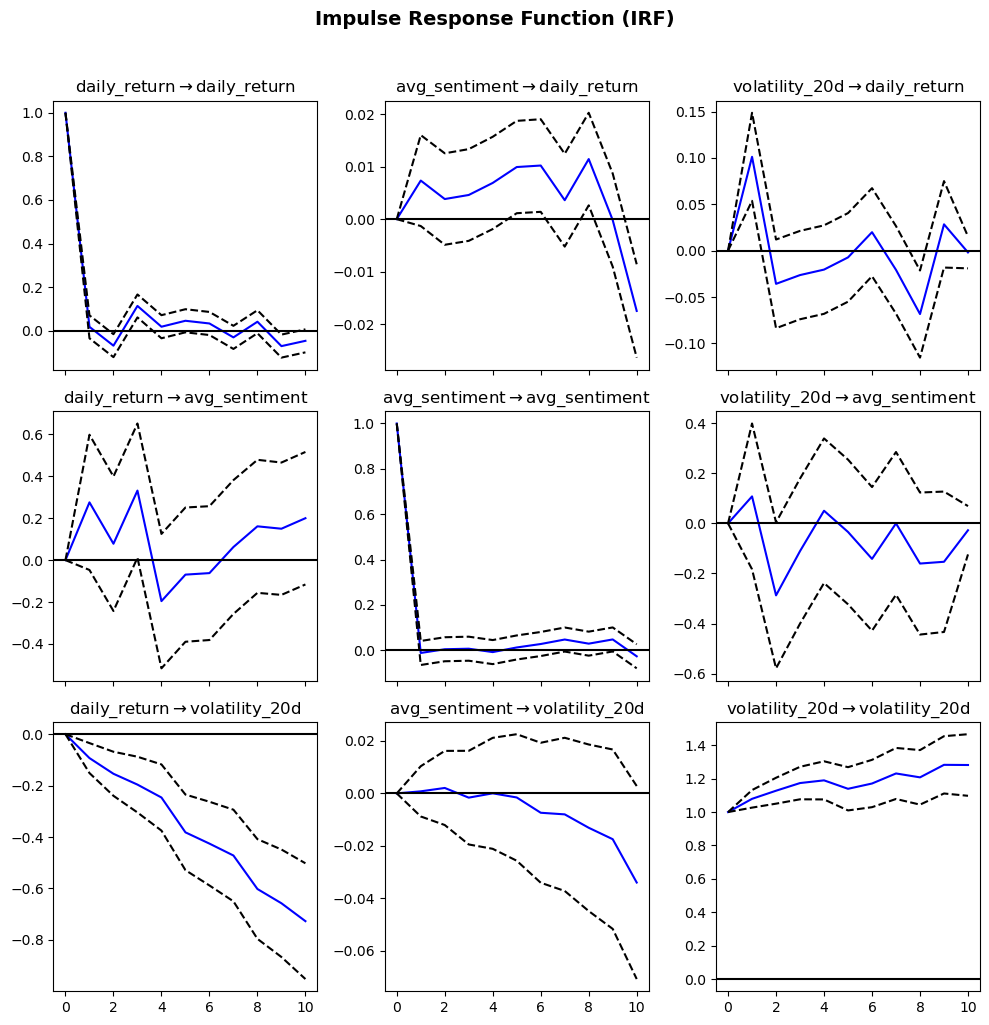

✅ IRF selesai
💾 Tersimpan: reports/figures/impulse_response_var.png


In [3]:
# ============================================================
# IMPULSE RESPONSE FUNCTION (IRF)
# ============================================================

print("⏳ Menghitung IRF...")
irf = results_var.irf(10)

fig = plt.figure(figsize=(12, 8))
irf.plot()
plt.suptitle('Impulse Response Function (IRF)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\impulse_response_var.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ IRF selesai")
print("💾 Tersimpan: reports/figures/impulse_response_var.png")

# FORECAST ERROR VARIANCE DECOMPOSITION


⏳ Menghitung FEVD...


<Figure size 1000x600 with 0 Axes>

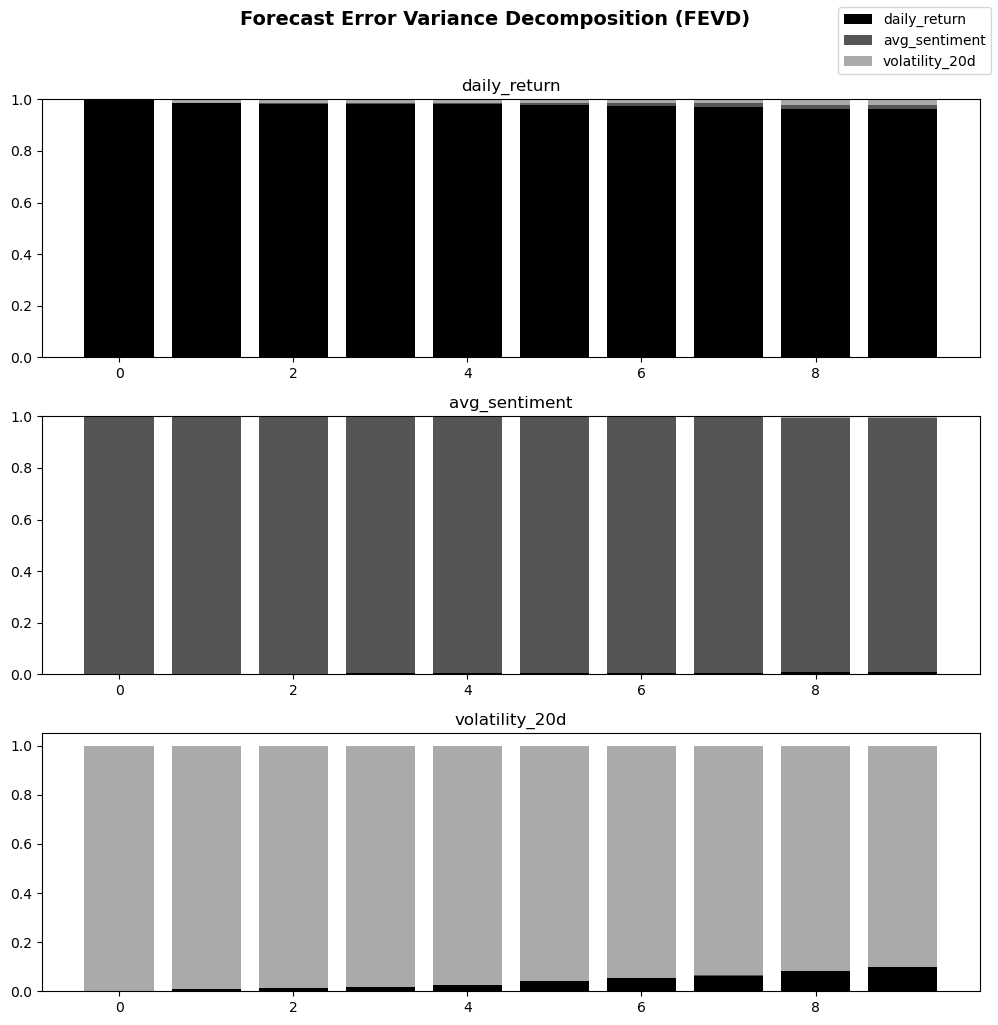

✅ FEVD selesai
💾 Tersimpan: reports/figures/fevd_var.png


In [4]:
# ============================================================
# FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# ============================================================
print("\n⏳ Menghitung FEVD...")
fevd = results_var.fevd(10)

fig = plt.figure(figsize=(10, 6))
fevd.plot()
plt.suptitle('Forecast Error Variance Decomposition (FEVD)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\fevd_var.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ FEVD selesai")
print("💾 Tersimpan: reports/figures/fevd_var.png")

# MULTIPLE REGRESSION

In [5]:
# ============================================================
# MULTIPLE REGRESSION (OLS)
# ============================================================
import statsmodels.api as sm

print("=" * 60)
print("MULTIPLE REGRESSION")
print("=" * 60)

# Siapkan data
df_reg = df[['daily_return', 'avg_sentiment', 'news_count', 'volatility_20d', 'sentiment_lag_1']].dropna()

y = df_reg['daily_return']
X = df_reg[['avg_sentiment', 'news_count', 'volatility_20d', 'sentiment_lag_1']]
X = sm.add_constant(X)

# Estimasi
model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

# Interpretasi cepat
print("\n📊 Interpretasi Koefisien:")
for var in ['avg_sentiment', 'sentiment_lag_1', 'news_count']:
    coef = model_ols.params[var]
    pval = model_ols.pvalues[var]
    status = "✅ SIGNIFIKAN" if pval < 0.05 else "❌ Tidak signifikan"
    print(f"   {var:20s}: coef = {coef:+.6f}, p = {pval:.4f} → {status}")

print(f"\n   R-squared = {model_ols.rsquared:.4f}")
print(f"   → Model menjelaskan {model_ols.rsquared*100:.2f}% variasi return IHSG")

MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:           daily_return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.265
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.282
Time:                        13:29:55   Log-Likelihood:                 4492.3
No. Observations:                1407   AIC:                            -8975.
Df Residuals:                    1402   BIC:                            -8948.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.

# ROBUSTNESS CHECK

In [6]:
# ============================================================
# ROBUSTNESS CHECK
# ============================================================
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

print("=" * 60)
print("ROBUSTNESS CHECK")
print("=" * 60)

# 4a. Durbin-Watson (Autokorelasi)
dw = sm.stats.durbin_watson(model_ols.resid)
print(f"\n Durbin-Watson: {dw:.4f}")
if 1.5 < dw < 2.5:
    print("   ✅ Tidak ada autokorelasi (DW ≈ 2)")
else:
    print("   ⚠️  Ada indikasi autokorelasi")

# 4b. VIF (Multikolinearitas)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(f"\n VIF (Variance Inflation Factor):")
print(vif_data.to_string(index=False))

if vif_data['VIF'].max() < 10:
    print("   ✅ Tidak ada multikolinearitas serius (VIF < 10)")
else:
    print("   ⚠️  Ada multikolinearitas (VIF ≥ 10)")

# 4c. ARCH-LM (Heteroskedastisitas)
arch_test = het_arch(model_ols.resid, maxlag=5)

print(f"\n ARCH-LM Test:")
print(f"   LM Statistic: {arch_test[0]:.4f}")
print(f"   p-value: {arch_test[1]:.4f}")

if arch_test[1] > 0.05:
    print("   ✅ Tidak ada heteroskedastisitas (homoskedastis)")
else:
    print("   ⚠️  Ada heteroskedastisitas → pertimbangkan robust standard errors")

ROBUSTNESS CHECK

 Durbin-Watson: 1.9765
   ✅ Tidak ada autokorelasi (DW ≈ 2)

 VIF (Variance Inflation Factor):
       Variable      VIF
          const 4.986040
  avg_sentiment 1.002451
     news_count 1.003290
 volatility_20d 1.005462
sentiment_lag_1 1.004521
   ✅ Tidak ada multikolinearitas serius (VIF < 10)

 ARCH-LM Test:
   LM Statistic: 231.6532
   p-value: 0.0000
   ⚠️  Ada heteroskedastisitas → pertimbangkan robust standard errors


C:\Users\ADVAN\AppData\Local\Temp\ipykernel_17824\574860889.py:34: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_test = het_arch(model_ols.resid, maxlag=5)


# VAR FORECASTING

VAR FORECASTING
Forecast 30 hari ke depan dari 2024-12-30:
        date  return_forecast  sentiment_forecast
0 2024-12-31         0.000746           -0.003715
1 2025-01-01         0.002776           -0.002863
2 2025-01-02         0.001085           -0.003928
3 2025-01-03         0.001306            0.000007
4 2025-01-06         0.001590            0.001282
5 2025-01-07        -0.000424            0.003471
6 2025-01-08        -0.000366            0.006042
7 2025-01-09         0.000859            0.001676
8 2025-01-10        -0.000117            0.001980
9 2025-01-13         0.000061            0.003548


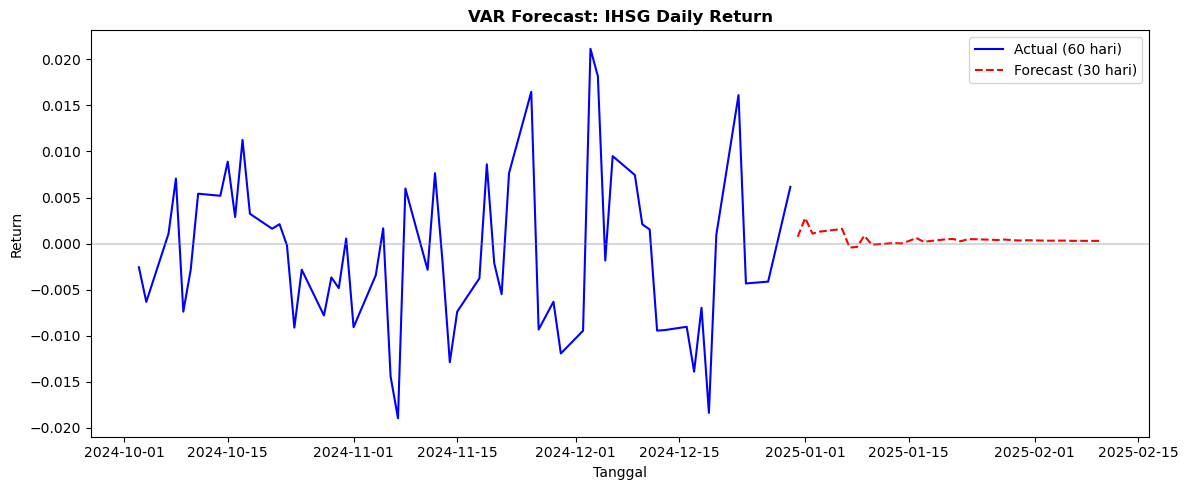


✅ Forecast selesai
💾 Tersimpan: reports/figures/var_forecast.png


In [7]:
# ============================================================
# VAR FORECASTING (30 HARI KE DEPAN)
# ============================================================
print("=" * 60)
print("VAR FORECASTING")
print("=" * 60)

n_forecast = 30
forecast = results_var.forecast(df_var.values[-optimal_lag:], steps=n_forecast)

# Buat tanggal forecast
last_date = df['date'].iloc[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), 
    periods=n_forecast, 
    freq='B'
)

df_forecast = pd.DataFrame(
    forecast, 
    columns=['return_forecast', 'sentiment_forecast', 'vol_forecast']
)
df_forecast['date'] = forecast_dates

print(f"Forecast {n_forecast} hari ke depan dari {last_date.date()}:")
print(df_forecast[['date', 'return_forecast', 'sentiment_forecast']].head(10))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'][-60:], df['daily_return'][-60:], label='Actual (60 hari)', color='blue')
ax.plot(df_forecast['date'], df_forecast['return_forecast'], label='Forecast (30 hari)', color='red', linestyle='--')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_title('VAR Forecast: IHSG Daily Return', fontweight='bold', fontsize=12)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Return')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\var_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Forecast selesai")
print("💾 Tersimpan: reports/figures/var_forecast.png")